<a href="https://colab.research.google.com/github/dongukl/dongukl-robot_danger_detection/blob/main/notebooks/02_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle -q
!apt-get install -y fonts-nanum -qq

Selecting previously unselected package fonts-nanum.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.font_manager as fmㅌ
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader

In [ ]:

# 나눔 폰트 경로 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)

# matplotlib 전역 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("한글 폰트 설정 완료!")

한글 폰트 설정 완료!


In [ ]:
from google.colab import files
files.upload()

# 인증 파일 위치 설정
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle 연결 완료!")

Saving kaggle.json to kaggle.json
Kaggle 연결 완료!


In [ ]:
# 다운로드
!wget "http://www.svcl.ucsd.edu/projects/anomaly/UCSD_Anomaly_Dataset.tar.gz" \
     -O /content/UCSD.tar.gz \
     --progress=bar:force 2>&1

--2026-05-17 04:59:23--  http://www.svcl.ucsd.edu/projects/anomaly/UCSD_Anomaly_Dataset.tar.gz
Resolving www.svcl.ucsd.edu (www.svcl.ucsd.edu)... 169.228.63.130
Connecting to www.svcl.ucsd.edu (www.svcl.ucsd.edu)|169.228.63.130|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 740306953 (706M) [application/x-gzip]
Saving to: ‘/content/UCSD.tar.gz’

/content/UCSD.tar.g 100%[===================>] 706.01M  97.1MB/s    in 9.9s    

2026-05-17 04:59:33 (71.2 MB/s) - ‘/content/UCSD.tar.gz’ saved [740306953/740306953]



In [ ]:
!mkdir -p /content/data
!tar -xzf /content/UCSD.tar.gz -C /content/data
print("압축 해제 완료!")

압축 해제 완료!


In [ ]:
# 폴더 구조 확인
# os.walk = 특정 경로 내에 존재하는 폴더(디렉토리)와 파일 리스트 뿐만 아니라, 모든 하위 디렉토리 구조를 다 검색
for root, dirs, files in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    if level > 3:
        continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 3:
        # 파일 3개만 미리보기
        for f in sorted(files)[:3]:
            print(f'{indent}  {f}')

data/
  UCSD_Anomaly_Dataset.v1p2/
    UCSDped1/
      Test/
        .DS_Store
        ._UCSDped1.m
        UCSDped1.m
      Train/
        .DS_Store
        ._.DS_Store
    UCSDped2/
      Test/
        .DS_Store
        ._.DS_Store
        ._UCSDped2.m
      Train/
        .DS_Store
        ._.DS_Store


총 훈련 프레임 수: 2550


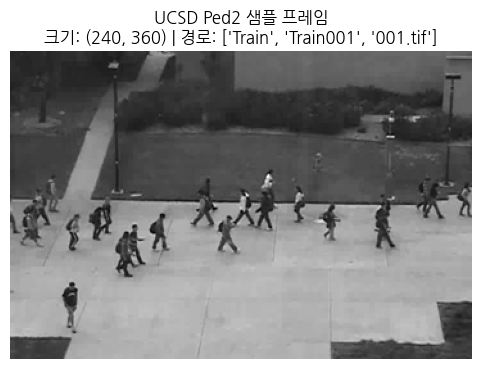

In [ ]:
# 샘플 이미지 1장 확인
# Ped2 훈련 프레임 찾기
frames = sorted(glob.glob('/content/data/**/UCSDped2/Train/**/*.tif', recursive=True))
print(f"총 훈련 프레임 수: {len(frames)}")

# 첫 번째 프레임 시각화
img = cv2.imread(frames[0], cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(6, 4))
plt.imshow(img, cmap='gray')
plt.title(f'UCSD Ped2 샘플 프레임\n크기: {img.shape} | 경로: {frames[0].split("/")[-3:]}')
plt.axis('off')
plt.show()

In [ ]:
BASE_PATH = '/content/data/UCSD_Anomaly_Dataset.v1p2/UCSDped1'
TRAIN_PATH = os.path.join(BASE_PATH, 'Train')
TEST_PATH = os.path.join(BASE_PATH, 'Test')

IMG_SIZE = (224, 224)

print(f'훈련 경로 : {TRAIN_PATH}')
print(f'테스트 경로 : {TEST_PATH}')
print(f'이미지 크기 : {IMG_SIZE}')

훈련 경로 : /content/data/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Train
테스트 경로 : /content/data/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Test
이미지 크기 : (224, 224)


In [ ]:
def load_frame(folder_path):
    # glob: 파일명을 리스트 형식으로 반환
    frame_paths = sorted(glob.glob(os.path.join(folder_path, '*.tif')))

    if len(frame_paths) == 0:
        return []
    frames = []
    for path in frame_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, IMG_SIZE)
        frames.append(img)
    return frames

train_folders = sorted(glob.glob(os.path.join(TRAIN_PATH, 'Train*')))
sample_frames = load_frame(train_folders[0])

print(f"훈련 영상 폴더 수 : {len(train_folders)}")
print(f"첫 번째 영상 프레임 수 : {len(sample_frames)}")
print(f"프레임 크기: {sample_frames[0].shape}")

훈련 영상 폴더 수 : 34
첫 번째 영상 프레임 수 : 200
프레임 크기: (224, 224)


In [ ]:
def compute_optical_flow(frame1, frame2):
    flow = cv2.calcOpticalFlowFarneback(
        frame1, frame2,
        None,
        pyr_scale=0.5,
        levels=3,
        winsize=15,
        iterations=3,
        poly_n=5,
        poly_sigma=1.2,
        flags=0
    )

    dx, dy = flow[..., 0], flow[..., 1]
    magnitude = np.sqrt(dx**2 + dy**2)
    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    magnitude = magnitude.astype(np.uint8)

    return magnitude

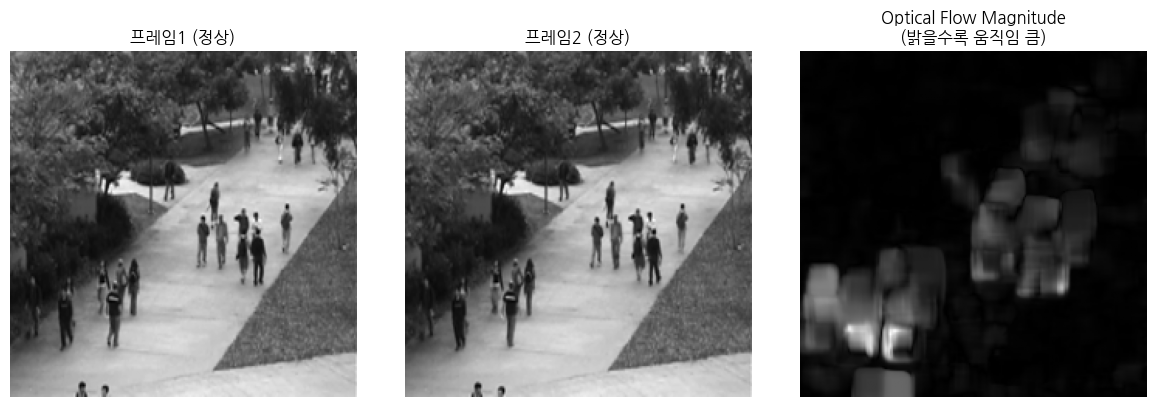

Flow map 크기: (224, 224)
Flow 최솟값: 0 최댓값: 255


In [ ]:
# 테스트
frame1 = sample_frames[0]
frame2 = sample_frames[1]
flow_map = compute_optical_flow(frame1, frame2)

fig, axes = plt.subplots(1,3, figsize=(12,4))

axes[0].imshow(frame1, cmap='gray')
axes[0].set_title('프레임1 (정상)')
axes[0].axis('off')

axes[1].imshow(frame2, cmap='gray')
axes[1].set_title('프레임2 (정상)')
axes[1].axis('off')


axes[2].imshow(flow_map, cmap='gray')
axes[2].set_title('Optical Flow Magnitude\n(밝을수록 움직임 큼)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f'Flow map 크기: {flow_map.shape}')
print(f'Flow 최솟값: {flow_map.min()} 최댓값: {flow_map.max()}')



In [ ]:
def build_dataset(train_path, test_path):
    flow_map = []
    labels = []

    train_folders = sorted(glob.glob(os.path.join(train_path, 'Train*')))
    print(f"훈련 영상 처리중... ({len(train_folders)}개)")
    for folder in train_folders:
        frames = load_frame(folder)
        for i in range(len(frames) - 1):
            flow = compute_optical_flow(frames[i], frames[i+1])
            flow_map.append(flow)
            labels.append(0)
    test_folders = sorted([
        f for f in glob.glob(os.path.join(test_path, 'Test*'))
        if '_gt' not in f
    ])
    print(f"테스트 영상 처리중...({len(test_folders)}개)")

    for folder in test_folders:
        frames = load_frame(folder)
        gt_folder = folder + '_gt'
        label = 1 if os.path.exists(gt_folder) else 0
        for i in range(len(frames) - 1):
            flow = compute_optical_flow(frames[i], frames[i+1])
            flow_map.append(flow)
            labels.append(label)

    return np.array(flow_map), np.array(labels)

flow_maps, labels = build_dataset(TRAIN_PATH, TEST_PATH)

print(f"\n전처리 완료")
print(f"전체 샘플 수 : {len(flow_maps)}")
print(f"정상(0): {np.sum(labels == 0)}개")
print(f"이상(1): {np.sum(labels == 1)}개")
print(f"shape: {flow_maps.shape}")


훈련 영상 처리중... (34개)
테스트 영상 처리중...(36개)

전처리 완료
전체 샘플 수 : 13930
정상(0): 11940개
이상(1): 1990개
shape: (13930, 224, 224)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    flow_maps, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"훈련데이터 : {len(X_train)} | 정상 : {sum(y_train == 0)} | 이상 : {sum(y_train == 1)}")
print(f"검증데이터 : {len(X_val)} | 정상 : {sum(y_val == 0)} | 이상 : {sum(y_val == 1)}")
print(f"테스트데이터 : {len(X_test)} | 정상 : {sum(y_test == 0)} | 이상 : {sum(y_test == 1)}")


훈련데이터 : 8915 | 정상 : 7641 | 이상 : 1274
검증데이터 : 2229 | 정상 : 1911 | 이상 : 318
테스트데이터 : 2786 | 정상 : 2388 | 이상 : 398


In [ ]:
class FlowDataset(Dataset):
    def __init__(self, flow_maps, labels):
        self.images = torch.FloatTensor(flow_maps).unsqueeze(1) / 255.0
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


train_dataset = FlowDataset(X_train, y_train)
val_dataset = FlowDataset(X_val, y_val)
test_dataset = FlowDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"훈련 데이터 로더 : {len(train_loader)}")
print(f"검증 데이터 로더 : {len(val_loader)}")
print(f"테스트 데이터 로더 : {len(test_loader)}")

images, labels_batch = next(iter(train_loader))
print(f"배치 이미지 크기 : {images.shape}")
print(f"배치 라벨 크기 : {labels_batch.shape}")

훈련 데이터 로더 : 279
검증 데이터 로더 : 70
테스트 데이터 로더 : 88
배치 이미지 크기 : torch.Size([32, 1, 224, 224])
배치 라벨 크기 : torch.Size([32])


In [ ]:
# 셀 1 - 라이브러리 임포트
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

사용 장치: cuda


In [ ]:
# 셀 2 - 모델 설정
def build_model():
    model = models.resnet18(pretrained=True)

    # 1채널로 수정
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # 전체 파라미터 고정
    for param in model.parameters():
        param.requires_grad = False

    # 마지막 레이어 + conv1만 학습
    model.fc = nn.Linear(model.fc.in_features, 2)
    for param in model.conv1.parameters():
        param.requires_grad = True

    return model.to(device)

model = build_model()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터: {total:,}")
print(f"학습 파라미터: {trainable:,} ({trainable/total*100:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


전체 파라미터: 11,171,266
학습 파라미터: 4,162 (0.0%)


In [ ]:
# ================================================================
# 1차 시도 - 클래스 가중치 3.5 적용
# 결과: Recall 0.87 / Precision 0.2~0.3 (오탐율 높음)
# 문제: 이상 가중치가 너무 높아 과도하게 이상으로 예측
# → 2차 시도에서 가중치 2.0으로 낮추고 재실행
# ================================================================
# 가중치 조정
# 클래스 불균형 해결 + 학습 설정
num_normal  = int((labels == 0).sum())
num_anomaly = int((labels == 1).sum())
total_count = num_normal + num_anomaly

weight_normal  = total_count / (2 * num_normal)
weight_anomaly = total_count / (2 * num_anomaly)

class_weights = torch.FloatTensor([weight_normal, weight_anomaly]).to(device)
print(f"정상 가중치:  {weight_normal:.2f}")
print(f"이상 가중치: {weight_anomaly:.2f}")

# 가중치 적용 손실 함수
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 학습률 높임
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

EPOCHS = 15
print(f"\n에폭: {EPOCHS} | 학습률: {optimizer.param_groups[0]['lr']}")

정상 가중치:  0.58
이상 가중치: 3.50

에폭: 15 | 학습률: 0.001


In [ ]:
# ================================================================
# 2차 시도 - 가중치 2.0, 학습률 5e-4, 에폭 20
# ================================================================
model = build_model()  # 모델 초기화

weight_normal  = 1.0
weight_anomaly = 2.0  # 기존 3.5 → 2.0으로 낮춤

class_weights = torch.FloatTensor([weight_normal, weight_anomaly]).to(device)

criterion  = nn.CrossEntropyLoss(weight=class_weights)
optimizer  = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4  # 학습률도 살짝 낮춤
)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 20  # 에폭 늘리기
print(f"이상 가중치: {weight_anomaly}")
print(f"학습률: {optimizer.param_groups[0]['lr']}")

이상 가중치: 2.0
학습률: 0.0005


In [ ]:
# ================================================================
# 3차 시도 - layer4 + conv1 + fc 학습, 가중치 3.5 유지
# 1차보다 더 많은 레이어 학습으로 특성 추출 능력 향상
# ================================================================

# 모델 초기화
def build_model():
    model = models.resnet18(pretrained=True)

    # 1채널로 수정
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # 전체 고정
    for param in model.parameters():
        param.requires_grad = False

    # conv1 + layer4 + fc 학습 허용 (1차보다 더 많이)
    for param in model.conv1.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, 2)

    return model.to(device)

model = build_model()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"학습 파라미터: {trainable:,} ({trainable/total*100:.1f}%)")
# 1차: 약 0.5% → 이번: 약 30% 로 늘어야 정상

학습 파라미터: 8,397,890 (75.2%)


In [ ]:
# 학습 설정 (1차 시도 가중치 그대로)
num_normal  = int((labels == 0).sum())
num_anomaly = int((labels == 1).sum())
total_count = num_normal + num_anomaly

weight_normal  = total_count / (2 * num_normal)
weight_anomaly = total_count / (2 * num_anomaly)

class_weights = torch.FloatTensor([weight_normal, weight_anomaly]).to(device)
print(f"정상 가중치:  {weight_normal:.2f}")
print(f"이상 가중치: {weight_anomaly:.2f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4  # layer4까지 학습하니 학습률 낮게 안정적으로
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 20
print(f"\n에폭: {EPOCHS} | 학습률: {optimizer.param_groups[0]['lr']}")

정상 가중치:  0.58
이상 가중치: 3.50

에폭: 20 | 학습률: 0.0001


In [ ]:
# 셀 4 - 학습 함수
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, label_batch in tqdm(loader, desc='훈련중'):
        images      = images.to(device)
        label_batch = label_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, label_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted   = outputs.argmax(dim=1)
        correct    += (predicted == label_batch).sum().item()
        total      += label_batch.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, label_batch in loader:
            images      = images.to(device)
            label_batch = label_batch.to(device)

            outputs  = model(images)
            loss     = criterion(outputs, label_batch)
            predicted = outputs.argmax(dim=1)

            total_loss += loss.item()
            correct    += (predicted == label_batch).sum().item()
            total      += label_batch.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(label_batch.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Recall: 실제 이상 중 맞춘 비율
    tp = ((all_preds == 1) & (all_labels == 1)).sum()
    fn = ((all_preds == 0) & (all_labels == 1)).sum()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    # Precision: 이상으로 예측한 것 중 실제 이상 비율
    fp = ((all_preds == 1) & (all_labels == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    return total_loss / len(loader), correct / total, recall, precision

In [ ]:
# 셀 5 - 학습 실행
train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []
val_recalls,  val_precisions = [], []

best_recall = 0
best_model_state = None

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer
    )
    val_loss, val_acc, val_recall, val_precision = evaluate(
        model, val_loader, criterion
    )
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_recalls.append(val_recall)
    val_precisions.append(val_precision)

    if val_recall > best_recall:
        best_recall = val_recall
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  ★ 최고 모델 갱신! Recall: {best_recall:.4f}")

    print(f"[{epoch+1:2d}/{EPOCHS}] "
          f"훈련손실: {train_loss:.4f} | 훈련정확도: {train_acc:.4f} | "
          f"검증손실: {val_loss:.4f} | 검증정확도: {val_acc:.4f} | "
          f"Recall: {val_recall:.4f} | Precision: {val_precision:.4f}")

훈련중: 100%|██████████| 279/279 [00:21<00:00, 12.85it/s]


  ★ 최고 모델 갱신! Recall: 0.9151
[ 1/20] 훈련손실: 0.4071 | 훈련정확도: 0.8101 | 검증손실: 0.2439 | 검증정확도: 0.8982 | Recall: 0.9151 | Precision: 0.5927


훈련중: 100%|██████████| 279/279 [00:22<00:00, 12.31it/s]


[ 2/20] 훈련손실: 0.0577 | 훈련정확도: 0.9822 | 검증손실: 0.2215 | 검증정확도: 0.9659 | Recall: 0.8333 | Precision: 0.9201


훈련중: 100%|██████████| 279/279 [00:23<00:00, 12.00it/s]


...

[18/20] 훈련손실: 0.0004 | 훈련정확도: 1.0000 | 검증손실: 0.1194 | 검증정확도: 0.9807 | Recall: 0.9182 | Precision: 0.9450


훈련중: 100%|██████████| 279/279 [00:22<00:00, 12.33it/s]


[19/20] 훈련손실: 0.0002 | 훈련정확도: 1.0000 | 검증손실: 0.1158 | 검증정확도: 0.9821 | Recall: 0.9214 | Precision: 0.9513


훈련중: 100%|██████████| 279/279 [00:22<00:00, 12.34it/s]


[20/20] 훈련손실: 0.0003 | 훈련정확도: 1.0000 | 검증손실: 0.1051 | 검증정확도: 0.9812 | Recall: 0.9308 | Precision: 0.9367


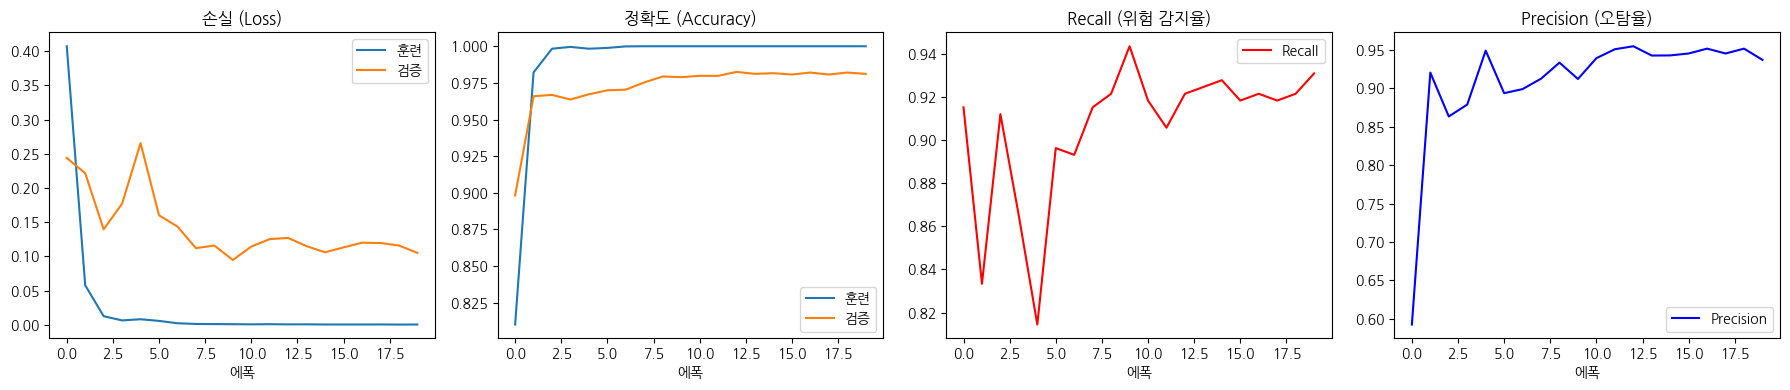


최고 Recall: 0.9434


In [ ]:
# 셀 6 - 학습 곡선 시각화
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(train_losses, label='훈련')
axes[0].plot(val_losses,   label='검증')
axes[0].set_title('손실 (Loss)')
axes[0].set_xlabel('에폭')
axes[0].legend()

axes[1].plot(train_accs, label='훈련')
axes[1].plot(val_accs,   label='검증')
axes[1].set_title('정확도 (Accuracy)')
axes[1].set_xlabel('에폭')
axes[1].legend()

axes[2].plot(val_recalls, color='red', label='Recall')
axes[2].set_title('Recall (위험 감지율)')
axes[2].set_xlabel('에폭')
axes[2].legend()

axes[3].plot(val_precisions, color='blue', label='Precision')
axes[3].set_title('Precision (오탐율)')
axes[3].set_xlabel('에폭')
axes[3].legend()

plt.tight_layout()
plt.show()

print(f"\n최고 Recall: {best_recall:.4f}")

In [ ]:
# 셀 7 - 예측 분포 확인 (모델이 뭘 예측하는지)
model.eval()
all_preds = []

with torch.no_grad():
    for images, _ in val_loader:
        images = images.to(device)
        outputs = model(images)
        predicted = outputs.argmax(dim=1)
        all_preds.extend(predicted.cpu().numpy())

all_preds = np.array(all_preds)
print(f"정상(0)으로 예측: {(all_preds == 0).sum()}개")
print(f"이상(1)으로 예측: {(all_preds == 1).sum()}개")

정상(0)으로 예측: 1913개
이상(1)으로 예측: 316개


In [ ]:
# 최고 Recall 모델 저장 (10에폭 시점)
torch.save(best_model_state, '/content/best_model.pth')
print("모델 저장 완료!")

모델 저장 완료!


In [ ]:
# 저장된 최고 모델로 테스트셋 평가
model.load_state_dict(best_model_state)
test_loss, test_acc, test_recall, test_precision = evaluate(
    model, test_loader, criterion
)

print("=" * 40)
print("최종 테스트 결과")
print("=" * 40)
print(f"정확도:    {test_acc:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"Precision: {test_precision:.4f}")
f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)
print(f"F1 Score:  {f1:.4f}")
print("=" * 40)

최종 테스트 결과
정확도:    0.9831
Recall:    0.9372
Precision: 0.9443
F1 Score:  0.9407


In [ ]:
# 구글 드라이브에 모델 저장
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/scene-risk-perception', exist_ok=True)

torch.save(best_model_state, '/content/drive/MyDrive/scene-risk-perception/best_model.pth')
print("드라이브 저장 완료!")

Mounted at /content/drive
드라이브 저장 완료!
